# Seeing the SVM Decision Boundary: how `C` and `gamma` control over/underfitting

**Technique:** Support Vector Machines (SVM) with the RBF kernel.
**Focus:** how the two key hyperparameters  the regularisation strength `C` and the
RBF kernel width `gamma`  jointly control the shape of the decision boundary and the
classic *bias variance tradeoff*.

This notebook is the complete, runnable code behind the tutorial. Every figure in the
tutorial is produced below. Run the cells top to bottom (Runtime ▸ Run all in Colab).



### How an SVM works (one paragraph)
An SVM finds the decision boundary that maximises the *margin*  the gap between the two
classes. `C` controls how much we penalise points that fall inside the margin or on the
wrong side: small `C` = wide, forgiving margin (more bias, less variance); large `C` =
hard margin that bends to fit training points (less bias, more variance). The **RBF
kernel** lets the boundary curve. Its `gamma` sets how far the influence of a single
training point reaches: small `gamma` = far-reaching, smooth boundary; large `gamma` =
short-reaching, wiggly boundary that can wrap individual points.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

RNG = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# Colourblind-safe palette (Okabe-Ito). We ALSO use different marker shapes
# (circle vs triangle) so the plots are readable without relying on colour.
C0, C1 = "#0072B2", "#D55E00"
CMAP_BG = ListedColormap(["#9ecae1", "#fdae6b"])

## 1. A dataset a straight line cannot separate

We use `make_moons`, two interleaving half-circles with noise. It is 2-D so we can
*draw* the decision boundary, and it is not linearly separable  which is exactly what
motivates the kernel trick.

In [2]:
X, y = make_moons(n_samples=300, noise=0.30, random_state=RNG)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RNG, stratify=y
)
print(f"Train: {X_train.shape[0]} points, Test: {X_test.shape[0]} points")

Train: 210 points, Test: 90 points


In [3]:
def plot_decision_boundary(ax, model, X, y, title, sv=None):
    """Draw an SVM's decision regions plus the data. Shapes distinguish classes."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=CMAP_BG)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c=C0, marker="o",
               edgecolor="k", linewidth=0.4, s=30, label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c=C1, marker="^",
               edgecolor="k", linewidth=0.4, s=30, label="Class 1")
    if sv is not None:  # circle the support vectors
        ax.scatter(sv[:, 0], sv[:, 1], s=140, facecolors="none",
                   edgecolors="k", linewidth=1.2, label="Support vectors")
    ax.set_title(title)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.legend(loc="upper right", fontsize=8)

### Why we need a kernel
A **linear** SVM can only draw a straight line, so it cannot follow the moon shapes.
An **RBF** SVM curves around them. (We standardise features first  SVMs are distance-based,
so scale matters.)

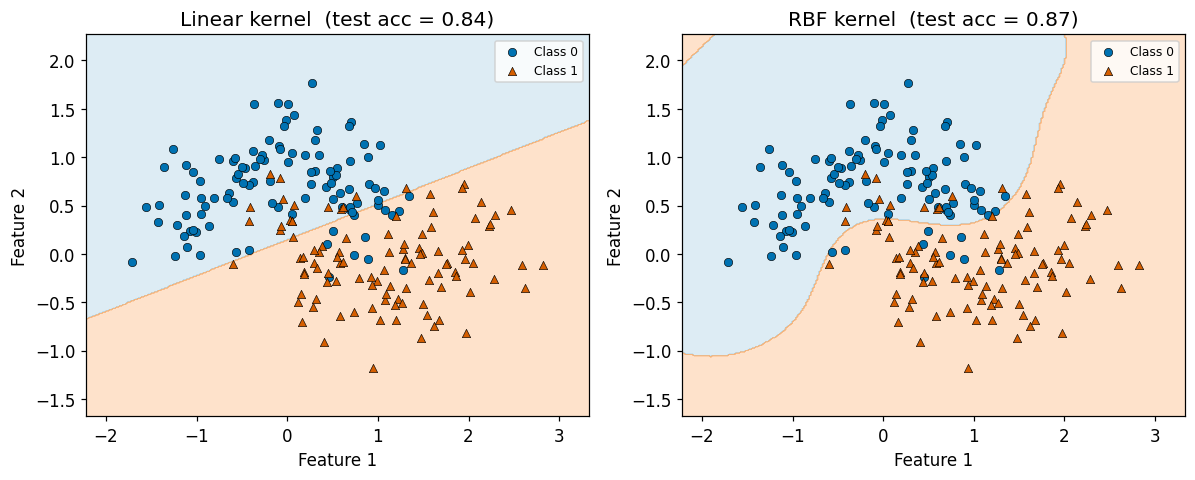

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
lin = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)).fit(X_train, y_train)
rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale")).fit(X_train, y_train)
plot_decision_boundary(axes[0], lin, X_train, y_train,
                       f"Linear kernel  (test acc = {lin.score(X_test, y_test):.2f})")
plot_decision_boundary(axes[1], rbf, X_train, y_train,
                       f"RBF kernel  (test acc = {rbf.score(X_test, y_test):.2f})")
fig.tight_layout(); plt.show()

## 2. The core idea: `gamma` is a complexity dial

Hold `C = 1` and sweep `gamma`. Watch the boundary go from **underfit** (too smooth) to
**just right** to **overfit** (islands wrapped around individual noisy points).

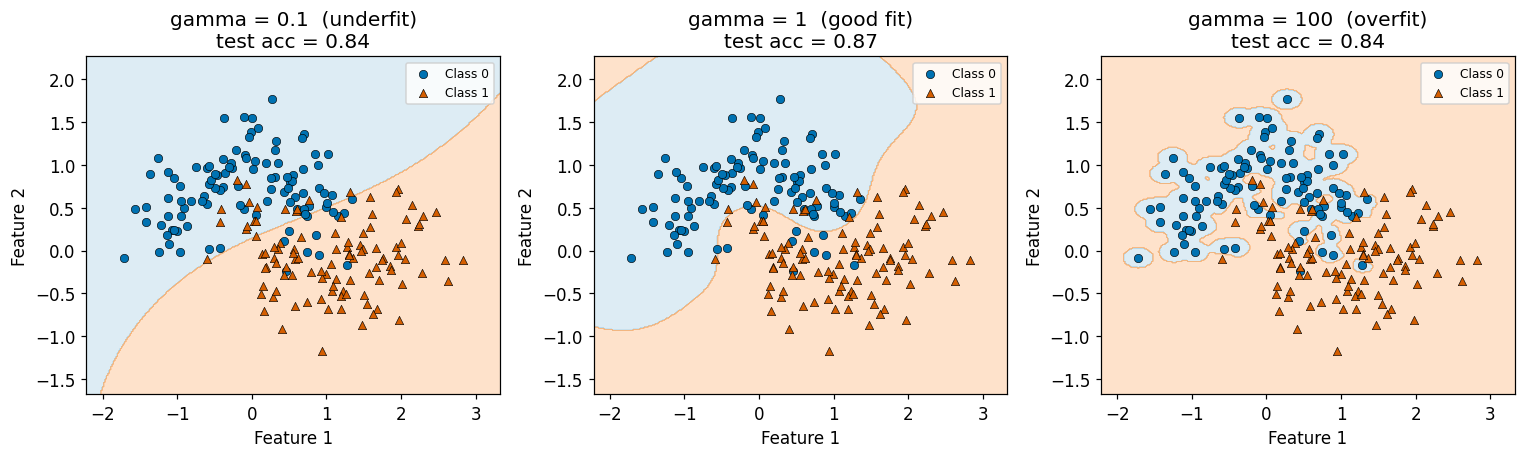

In [5]:
gammas = [0.1, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, g in zip(axes, gammas):
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=g)).fit(X_train, y_train)
    label = {0.1: "underfit", 1: "good fit", 100: "overfit"}[g]
    plot_decision_boundary(ax, m, X_train, y_train,
                           f"gamma = {g}  ({label})\ntest acc = {m.score(X_test, y_test):.2f}")
fig.tight_layout(); plt.show()

## 3. Making the tradeoff quantitative

The pictures above are qualitative. Here we plot **training vs test accuracy** as
`gamma` grows. The signature of overfitting: training accuracy keeps climbing toward 1.0
while test accuracy peaks and then falls. The gap between the curves *is* the variance.

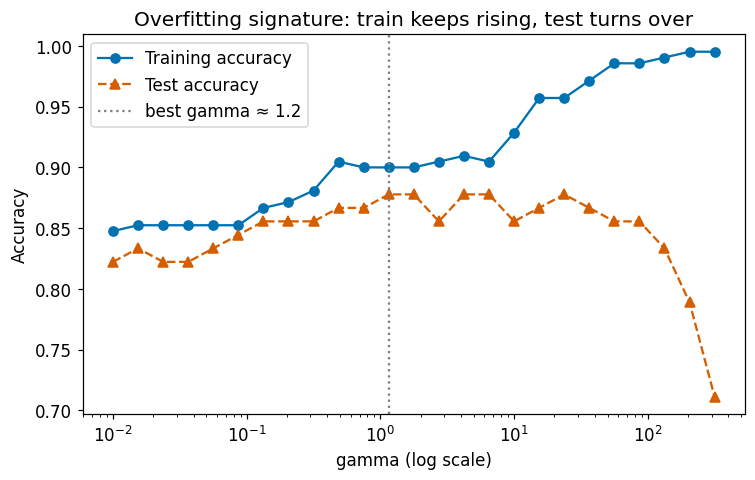

In [6]:
gs = np.logspace(-2, 2.5, 25)
train_acc, test_acc = [], []
for g in gs:
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=g)).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(gs, train_acc, "o-", color=C0, label="Training accuracy")
ax.semilogx(gs, test_acc, "^--", color=C1, label="Test accuracy")
best = gs[int(np.argmax(test_acc))]
ax.axvline(best, color="grey", ls=":", label=f"best gamma ≈ {best:.2g}")
ax.set_xlabel("gamma (log scale)"); ax.set_ylabel("Accuracy")
ax.set_title("Overfitting signature: train keeps rising, test turns over")
ax.legend(); fig.tight_layout(); plt.show()

## 4. What `C` does (the soft margin)

`gamma` sets boundary *flexibility*; `C` sets how *strict* we are about misclassifying
training points. Small `C` tolerates errors for a smoother, wider margin; large `C`
forces the boundary to fit the training data more tightly.

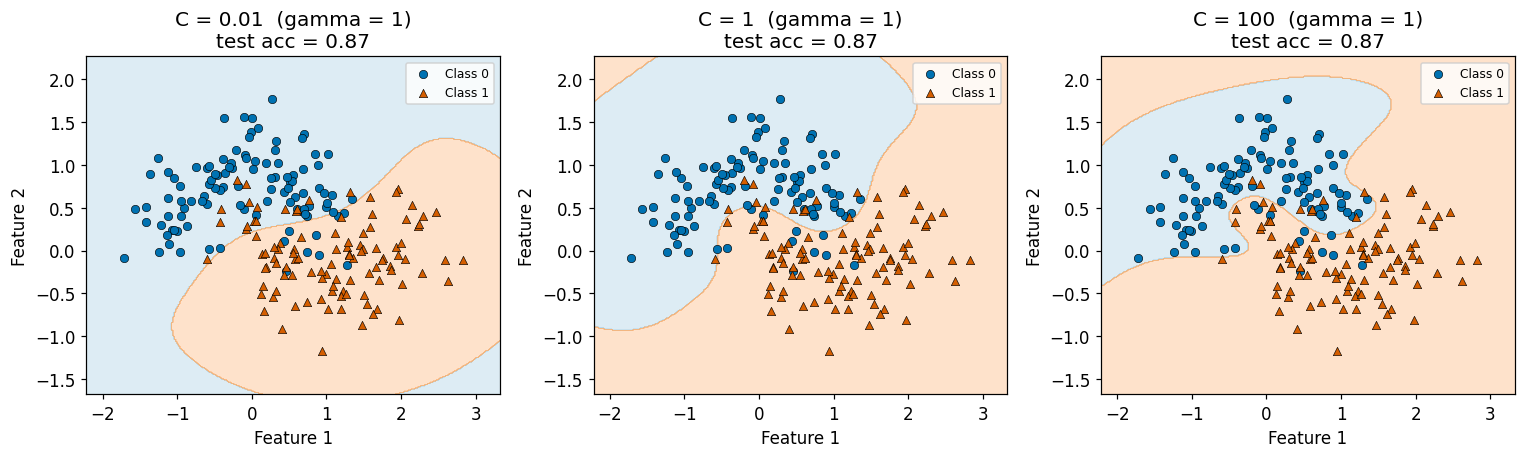

In [7]:
Cs = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, c in zip(axes, Cs):
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=c, gamma=1.0)).fit(X_train, y_train)
    plot_decision_boundary(ax, m, X_train, y_train,
                           f"C = {c}  (gamma = 1)\ntest acc = {m.score(X_test, y_test):.2f}")
fig.tight_layout(); plt.show()

## 5. Choosing them together: cross-validated `C` × `gamma`

In practice you never tune by eye. We grid over both hyperparameters and score each
combination with **5-fold cross-validation**. The heatmap reveals a "sweet ridge" of
good settings and a dark overfitting/underfitting region around it.

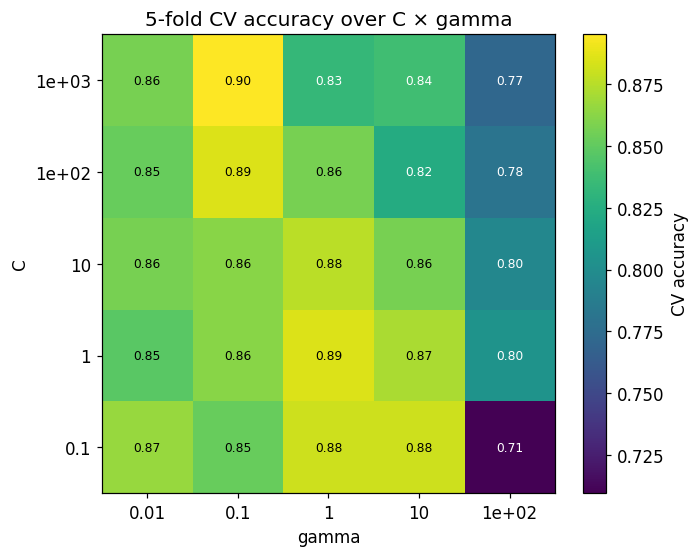

Best CV accuracy 0.895 at C=1e+03, gamma=0.1


In [8]:
Cs = np.logspace(-1, 3, 5)
Gs = np.logspace(-2, 2, 5)
heat = np.zeros((len(Cs), len(Gs)))
for i, c in enumerate(Cs):
    for j, g in enumerate(Gs):
        pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=c, gamma=g))
        heat[i, j] = cross_val_score(pipe, X_train, y_train, cv=5).mean()

fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(heat, cmap="viridis", origin="lower", aspect="auto")
ax.set_xticks(range(len(Gs))); ax.set_xticklabels([f"{g:.2g}" for g in Gs])
ax.set_yticks(range(len(Cs))); ax.set_yticklabels([f"{c:.2g}" for c in Cs])
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title("5-fold CV accuracy over C × gamma")
for i in range(len(Cs)):
    for j in range(len(Gs)):
        ax.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center",
                color="white" if heat[i, j] < heat.max() - 0.05 else "black", fontsize=8)
fig.colorbar(im, label="CV accuracy"); fig.tight_layout(); plt.show()

bi, bj = np.unravel_index(heat.argmax(), heat.shape)
print(f"Best CV accuracy {heat.max():.3f} at C={Cs[bi]:.2g}, gamma={Gs[bj]:.2g}")

## 6. What the SVM actually 'remembers': support vectors

An SVM's boundary depends only on a subset of the training points  the **support
vectors** that sit on or inside the margin. Below they are circled. Notice how few
points truly define the model; this is part of why SVMs can generalise well.

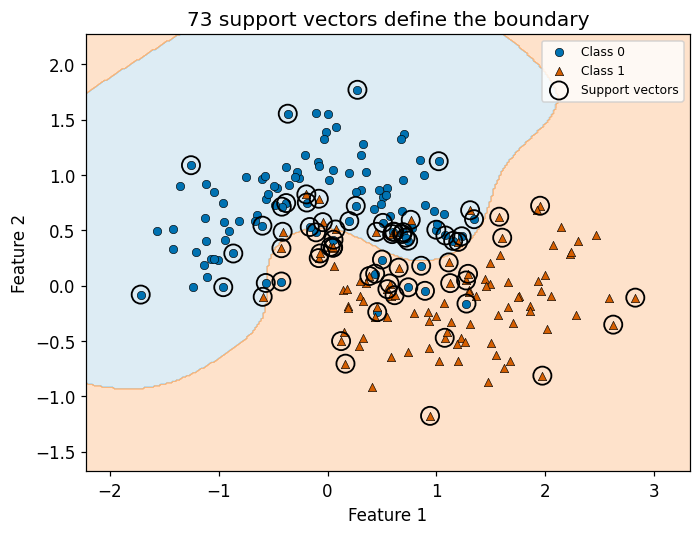

In [9]:
scaler = StandardScaler().fit(X_train)
Xs = scaler.transform(X_train)
svm = SVC(kernel="rbf", C=1.0, gamma=1.0).fit(Xs, y_train)
sv_original = scaler.inverse_transform(svm.support_vectors_)

fig, ax = plt.subplots(figsize=(6.5, 5))
pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=1.0)).fit(X_train, y_train)
plot_decision_boundary(ax, pipe, X_train, y_train,
                       f"{len(svm.support_)} support vectors define the boundary", sv=sv_original)
fig.tight_layout(); plt.show()

## Takeaways

- `gamma` is a **complexity dial**: too small underfits (high bias), too large overfits (high variance).
- `C` controls the **soft margin**: how much training error you tolerate for a simpler boundary.
- They interact  always tune them **together** with cross-validation, not one at a time.
- Standardise features first; SVMs are distance-based.
- The model is defined by a handful of **support vectors**.

## References
Replace/extend these with the exact sources you actually read:

1. Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning, 20(3), 273–297.
2. scikit-learn documentation  *Support Vector Machines* and *RBF SVM parameters*
   (https://scikit-learn.org/stable/modules/svm.html).
3. Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning*, Ch. 12.

